**Author**: Felipe Matheus  
**Start Date**: 06/05/2026  
**End Date**: 19/06/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm
from autogluon.tabular import TabularPredictor


module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from src.metrics.Evaluation import Evaluation
from src.DataLoader import LoaderHelper

from config.Variables import Variables

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
modl = Modeling()
evla = Evaluation()
varv = Variables()
load = LoaderHelper()


## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [3]:
# ---- Experiment settings ----
TAG = "notebook_test_11082026"
SCHEMA_DATE = "110826"

# ---- Paths ----
FILE_NAME = "dataset_annealing_iacs.csv"
FILE_NAME_SCHEMA_DATA = "schema_annealing_essays_{}.csv".format(SCHEMA_DATE)
FILE_NAME_VALIDATION_DATA = "Experimental Results Annealing V2 - CompiledResults.csv"

PROCESS = "annealing_iacs"

# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(varv.PATHS.models, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "iacs_final"
FEATURES = ["initial_diameter", "purity", "iacs", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "medium_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of sigma2_aleat as fraction of Var(y), in case of predictions as "100% sure" it still adds  small variance
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
USE_SHARED_FOLDS = False           # same fold_id column on both engines
FOLD_SEED = 42

# ---- Physical constraints (inference-time) ----
Y_MAX = 105.0                     # physical ceiling for %IACS


# 2. Data

## 2.1 Schema data

In [4]:
df, df_val = proc.process_annealing_iacs(
    features=FEATURES,
    target=TARGET,
    df_schema=pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME_SCHEMA_DATA)),
    df_val = proc.load_validation_data_chimie_paris(
        path=os.path.join(varv.PATHS.data_processed, FILE_NAME_VALIDATION_DATA)
)
)

In [5]:
df

,initial_diameter,purity,iacs,temperature,time,iacs_final
3,2.160000,99.9000,99.825,573.0,30.0,102.340000
4,2.182333,99.9000,99.390,573.0,30.0,102.230000
5,2.182333,99.9000,99.390,588.0,30.0,101.346667
6,2.191700,99.9000,99.230,573.0,30.0,101.355000
7,2.196300,99.9000,98.720,573.0,30.0,101.480000
8,1.200000,99.9000,97.710,523.0,30.0,100.290000
9,1.200000,99.9000,97.710,523.0,60.0,100.420000
10,1.200000,99.9000,97.710,523.0,90.0,100.290000
11,1.200000,99.9000,97.710,573.0,30.0,101.350000
12,1.200000,99.9000,97.710,573.0,60.0,101.350000


## 2.4 Validation data

In [6]:
df_val

,id,purity,initial_diameter,iacs,temperature,time,iacs_final
0,C1_250_30m_T1,99.95,1.2,98.47,523,30,101.08
1,C1_250_30m_T3,99.95,1.2,98.47,523,30,101.08
2,C1_250_60m_T1,99.95,1.2,98.47,523,60,100.82
3,C1_250_60m_T2,99.95,1.2,98.47,523,60,100.82
4,C1_250_90m_T1,99.95,1.2,98.47,523,90,101.22
5,C1_250_90m_T2,99.95,1.2,98.47,523,90,101.22
6,C1_250_30m_AQ_T1,99.95,1.2,98.47,523,30,100.95
7,C1_250_30m_AQ_T2,99.95,1.2,98.47,523,30,100.95
8,C1_300_30m_T1,99.95,1.2,98.47,573,30,102.03
9,C1_300_30m_T2,99.95,1.2,98.47,573,30,102.03


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [7]:
df.head(10)

,initial_diameter,purity,iacs,temperature,time,iacs_final
3,2.160000,99.9,99.825,573.0,30.0,102.340000
4,2.182333,99.9,99.390,573.0,30.0,102.230000
5,2.182333,99.9,99.390,588.0,30.0,101.346667
6,2.191700,99.9,99.230,573.0,30.0,101.355000
7,2.196300,99.9,98.720,573.0,30.0,101.480000
8,1.200000,99.9,97.710,523.0,30.0,100.290000
9,1.200000,99.9,97.710,523.0,60.0,100.420000
10,1.200000,99.9,97.710,523.0,90.0,100.290000
11,1.200000,99.9,97.710,573.0,30.0,101.350000
12,1.200000,99.9,97.710,573.0,60.0,101.350000


In [8]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    # groups="fold_id" if USE_SHARED_FOLDS else None,
    # sample_weight="weight_col",
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       6.71 GB / 31.57 GB (21.3%)
Disk Space Avail:   726.96 GB / 932.08 GB (78.0%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\notebook_test_11082026\model_a"
Train Data Rows:    39
Train Data Columns: 5
Label Column:       iacs_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (104.865, 98.355, 101.56697, 1.92333)
	If 'regressio

In [9]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.940440,root_mean_squared_error,0.178177,17.685576,0.000000,0.012510,2,True,10
1,CatBoost_BAG_L1,-0.956567,root_mean_squared_error,0.015003,3.866794,0.015003,3.866794,1,True,4
2,ExtraTreesMSE_BAG_L1,-0.982430,root_mean_squared_error,0.118188,0.801448,0.118188,0.801448,1,True,5
3,RandomForestMSE_BAG_L1,-1.024779,root_mean_squared_error,0.075636,1.127238,0.075636,1.127238,1,True,3
4,LightGBMLarge_BAG_L1,-1.058063,root_mean_squared_error,0.004094,1.991733,0.004094,1.991733,1,True,9
5,XGBoost_BAG_L1,-1.106763,root_mean_squared_error,0.025182,3.287286,0.025182,3.287286,1,True,7
6,NeuralNetTorch_BAG_L1,-1.314788,root_mean_squared_error,0.044986,13.004825,0.044986,13.004825,1,True,8
7,NeuralNetFastAI_BAG_L1,-1.916798,root_mean_squared_error,0.059655,14.652028,0.059655,14.652028,1,True,6
8,LightGBM_BAG_L1,-1.924643,root_mean_squared_error,0.002000,1.737883,0.002000,1.737883,1,True,2
9,LightGBMXT_BAG_L1,-1.924643,root_mean_squared_error,0.003667,2.764518,0.003667,2.764518,1,True,1


In [10]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.940440,root_mean_squared_error,0.178177,17.685576,0.000000,0.012510,2,True,10
1,CatBoost_BAG_L1,-0.956567,root_mean_squared_error,0.015003,3.866794,0.015003,3.866794,1,True,4
2,ExtraTreesMSE_BAG_L1,-0.982430,root_mean_squared_error,0.118188,0.801448,0.118188,0.801448,1,True,5
3,RandomForestMSE_BAG_L1,-1.024779,root_mean_squared_error,0.075636,1.127238,0.075636,1.127238,1,True,3
4,LightGBMLarge_BAG_L1,-1.058063,root_mean_squared_error,0.004094,1.991733,0.004094,1.991733,1,True,9
5,XGBoost_BAG_L1,-1.106763,root_mean_squared_error,0.025182,3.287286,0.025182,3.287286,1,True,7
6,NeuralNetTorch_BAG_L1,-1.314788,root_mean_squared_error,0.044986,13.004825,0.044986,13.004825,1,True,8
7,NeuralNetFastAI_BAG_L1,-1.916798,root_mean_squared_error,0.059655,14.652028,0.059655,14.652028,1,True,6
8,LightGBM_BAG_L1,-1.924643,root_mean_squared_error,0.002000,1.737883,0.002000,1.737883,1,True,2
9,LightGBMXT_BAG_L1,-1.924643,root_mean_squared_error,0.003667,2.764518,0.003667,2.764518,1,True,1


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [12]:
aml_h2o = modl.fit_h2o_automl(
    df= df,
    target= TARGET,
    features= FEATURES,
    weight_on_essay_rows= WEIGHT_ON_ESSAY_ROWS,
    num_bag_folds= NUM_BAG_FOLDS_A,
    use_shared_folds= USE_SHARED_FOLDS,
    time_limit= TIME_LIMIT_A
)

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,6 mins 12 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,4 months and 30 days
H2O_cluster_name:,H2O_from_python_fmfoa_nytf0g
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.976 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
11:06:28.531: AutoML: XGBoost is not available; skipping it.
11:06:28.927: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 39.0.

██████████████████████████████████████████████████████████████| (done) 100%


In [13]:
# NOTE: the previous cell here compared AutoGluon's `score_val` against
# H2O's xval RMSE. That comparison is incoherent when sample weights are
# active: H2O's xval RMSE is WEIGHTED by weights_column, while AutoGluon's
# score_val is UNWEIGHTED unless weight_evaluation=True. The fair,
# like-for-like comparison (unweighted metrics on OOF predictions of both
# engines, same y_true, same folds when USE_SHARED_FOLDS) is done in
# Section 10 ("OOF metrics: AutoGluon vs H2O").
print("See Section 10 for the coherent OOF-vs-OOF comparison.")


See Section 10 for the coherent OOF-vs-OOF comparison.


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [14]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = df[TARGET] - mu_oof
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(39,)  any NaN? False


## 4.1 fast check on big residuals

In [15]:
residuals_oof.head(10)

3     0.100971
4     0.568531
5    -0.651861
6    -0.542659
7     0.164776
8    -0.400125
9    -0.619383
10   -0.904557
11    0.730470
12    0.561174
Name: iacs_final, dtype: float64

In [16]:
df[residuals_oof.abs() > 2]

,initial_diameter,purity,iacs,temperature,time,iacs_final
25,1.2,99.9800,102.7,573.0,60.0,100.785
39,2.0,99.9558,97.4,573.0,30.0,98.960


In [17]:
mu_oof[residuals_oof.abs() > 2]

25    103.374016
39    101.260292
Name: iacs_final, dtype: float32

## 4.2 Recovering weights 

In [18]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (9, 39)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1']


In [19]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000004  (OK)

Non-zero weights:
  CatBoost_BAG_L1                 0.5789
  ExtraTreesMSE_BAG_L1            0.3684
  NeuralNetTorch_BAG_L1           0.0526


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [20]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

mu_diffs = np.abs(mu_recomputed - mu_oof)
mu_diffs.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof):.4f}")
# print(f"  max    = {sigma2_epist_oof.max():.4f}")

count    3.900000e+01
mean     1.807703e-06
std      9.753730e-07
min      2.395323e-07
25%      9.260585e-07
50%      1.861150e-06
75%      2.554731e-06
max      4.221229e-06
Name: iacs_final, dtype: float64

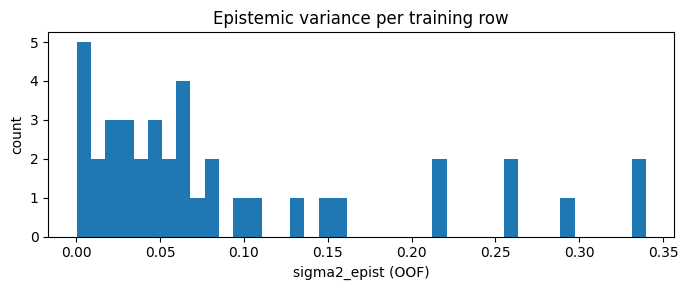

In [21]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

In [22]:
mu_recomputed_lin, sigma2_epist_oof_lin = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

mu_diffs_lin = np.abs(mu_recomputed_lin - mu_oof)
mu_diffs_lin.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
# print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

count    39.000000
mean      0.411939
std       0.287746
min       0.041702
25%       0.195827
50%       0.344627
75%       0.664349
max       1.068787
Name: iacs_final, dtype: float64

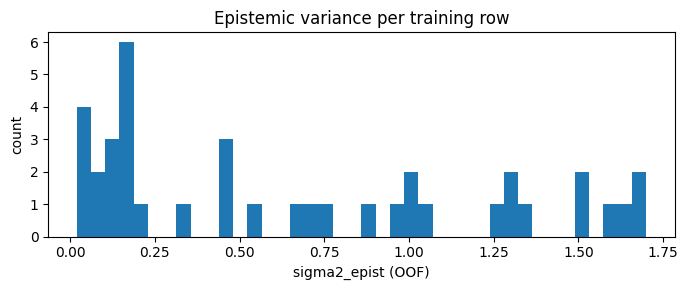

In [23]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Section 5 Conclusion
When number of lines is at least > 40 

Linear shows way more errors between the recomputed values. Weighted one is corrected.

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [24]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 39
  n_truncated          = 6
  pct_truncated        = 15.384615384615385
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 6.636260198470447
  r_tilde_sq_mean      = 0.8040569408777924
  r_tilde_sq_median    = 0.3205922678991161


In [25]:
r_tilde_sq

array([0.        , 0.32059227, 0.41547071, 0.29418686, 0.02501362,
       0.11501166, 0.33360123, 0.76254549, 0.47241838, 0.23005922,
       0.06899424, 0.11609875, 0.        , 0.16672702, 0.24808731,
       0.17754918, 0.36164998, 0.        , 0.        , 0.63962639,
       0.0427826 , 0.42724307, 6.6362602 , 2.50047489, 0.52869442,
       0.51773093, 0.09733441, 1.03089514, 2.26751622, 0.        ,
       0.8561863 , 0.3170436 , 0.        , 0.20650152, 1.17364942,
       3.33219951, 5.2861163 , 1.06121554, 0.32874431])

# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [26]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       3.02 GB / 31.57 GB (9.6%)
Disk Space Avail:   730.21 GB / 932.08 GB (78.3%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\notebook_test_11082026\model_b"
Train Data Rows:    39
Train Data Columns: 5
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (1.8925487323839678, -13.815510557964274, -2.86285

In [27]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-4.424241,root_mean_squared_error,0.336168,7.515619,0.000000,0.010184,2,True,10
1,NeuralNetTorch_BAG_L1,-4.425512,root_mean_squared_error,0.031543,6.752012,0.031543,6.752012,1,True,8
2,LightGBMLarge_BAG_L1,-4.946099,root_mean_squared_error,0.304625,0.753423,0.304625,0.753423,1,True,9
3,CatBoost_BAG_L1,-4.961499,root_mean_squared_error,0.008029,2.226255,0.008029,2.226255,1,True,4
4,LightGBM_BAG_L1,-5.024195,root_mean_squared_error,0.003005,1.311897,0.003005,1.311897,1,True,2
5,LightGBMXT_BAG_L1,-5.024195,root_mean_squared_error,0.005022,0.704189,0.005022,0.704189,1,True,1
6,XGBoost_BAG_L1,-5.026266,root_mean_squared_error,0.010517,0.808286,0.010517,0.808286,1,True,7
7,NeuralNetFastAI_BAG_L1,-5.132562,root_mean_squared_error,0.063859,10.289748,0.063859,10.289748,1,True,6
8,ExtraTreesMSE_BAG_L1,-5.947679,root_mean_squared_error,0.065323,0.522120,0.065323,0.522120,1,True,5
9,RandomForestMSE_BAG_L1,-6.067373,root_mean_squared_error,0.107965,0.559389,0.107965,0.559389,1,True,3


In [28]:
predictor_b.predict_oof()  

3    -4.972777
4    -4.973005
5    -1.107402
6    -1.122822
7    -1.352670
8    -0.158725
9    -4.231106
10   -4.309961
11   -3.495135
12   -3.820236
13   -2.250160
14   -3.441612
15   -3.817839
16   -5.208807
17   -2.363121
18   -2.904511
19   -5.096185
20   -5.072980
21   -3.987963
22   -4.329000
23   -1.096975
24    0.106940
25    0.378797
26    1.105600
27    1.059898
28   -4.180073
29   -0.330858
30   -4.806943
31   -1.470577
32   -4.613178
33   -2.067980
34   -4.829583
35   -4.778641
36   -1.432072
37   -1.220290
38   -4.788420
39   -1.125913
40   -2.527371
41   -4.272098
Name: log_r_tilde_sq, dtype: float32

In [29]:
df_lado_a_lado = pd.DataFrame({
    "residual_oof": residuals_oof,
    "predict_random_error": predictor_b.predict_oof()  , 
    "epistemic_error": sigma2_epist_oof,
    "iacs": df["iacs"],
    "iacs_final": df[TARGET]
}) 
df_lado_a_lado

,residual_oof,predict_random_error,epistemic_error,iacs,iacs_final
3,0.100971,-4.972777,0.025890,99.825,102.340000
4,0.568531,-4.973005,0.002636,99.390,102.230000
5,-0.651861,-1.107402,0.009452,99.390,101.346667
6,-0.542659,-1.122822,0.000292,99.230,101.355000
7,0.164776,-1.352670,0.002138,98.720,101.480000
8,-0.400125,-0.158725,0.045088,97.710,100.290000
9,-0.619383,-4.231106,0.050034,97.710,100.420000
10,-0.904557,-4.309961,0.055678,97.710,100.290000
11,0.730470,-3.495135,0.061168,97.710,101.350000
12,0.561174,-3.820236,0.084857,97.710,101.350000


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [30]:
df[TARGET].var()

np.float64(3.699212992565972)

Real coverage considering sigmas calculated so far

Build the predictive distribution. Not totally OOF cause model b is not generating OOF preds, we assume it's optimistic just a bit too small to be considered.


In [31]:
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
cal_before

=== Calibration BEFORE recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.179487,-0.320513
1,0.80,0.384615,-0.415385
2,0.90,0.538462,-0.361538
3,0.95,0.615385,-0.334615


Fit a scalar recalibration factor to pull coverage using α=0.9 as nominal reference


In [32]:
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
cal_after

Recalibration scalar c = 2.2471

=== Calibration AFTER recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.487179,-0.012821
1,0.80,0.820513,0.020513
2,0.90,0.897436,-0.002564
3,0.95,0.897436,-0.052564


# 8.1 Validation Set Evaluation

Evaluate the freshly trained pair (A + B, with the recalibration $c$) on a
validation DataFrame.

`modl.predict_target` is target-agnostic: it accepts a DataFrame **or a dict**
and any AutoGluon predictor (IACS, UTS, Model B...), inferring the features
from the predictor when not given.

In [33]:
c_opt
weights

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 5.78944682e-01,
       3.68422841e-01, 6.34713519e-08, 2.54984447e-07, 5.26318027e-02,
       3.55351962e-07])

In [34]:
len(base_model_names)
len(weights)

9

In [35]:
# ---- Validation set: df_schema (illustrative; in-sample, see caveat) ----
# df_val = df_schema.copy()

# Full calibrated predictive distribution on the validation set.
preds_val = modl.predict_with_uncertainty(
    X=df_val, # df_schema.copy()
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,
)

val_metrics = evla.metrics_on_dataframe(
    df=df_val, #df_schema.copy()
    target=TARGET,
    mu=preds_val["mu"].to_numpy(),
    sigma=preds_val["sigma_total"].to_numpy(),
    alphas=CALIBRATION_ALPHAS,
)
print("=== Validation metrics (df_schema) ===")
print({k: round(v, 4) for k, v in val_metrics.items() if k != "coverage"})
print("coverage:", {a: round(c, 3) for a, c in val_metrics["coverage"].items()})

=== Validation metrics (df_schema) ===
{'rmse': 0.3936, 'mae': 0.3049, 'mape': 0.3019, 'r2': 0.2995}
coverage: {0.5: 0.833, 0.8: 0.944, 0.9: 0.944, 0.95: 0.944}


In [36]:
# ---- Target-agnostic point prediction from a plain dict ----
single = modl.predict_target(
    predictor_a,
    {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
)
print(f"Predicted {TARGET}: {single[0]:.3f}")

Predicted iacs_final: 100.822


# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [37]:
df.head(5)

,initial_diameter,purity,iacs,temperature,time,iacs_final
3,2.160000,99.9,99.825,573.0,30.0,102.340000
4,2.182333,99.9,99.390,573.0,30.0,102.230000
5,2.182333,99.9,99.390,588.0,30.0,101.346667
6,2.191700,99.9,99.230,573.0,30.0,101.355000
7,2.196300,99.9,98.720,573.0,30.0,101.480000


In [38]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = modl.fit_ood_reference(df, features=FEATURES)

preds = modl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,          # physical ceiling -> mu_trunc / sigma_trunc / p_above_max
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds


,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,102.362876,0.010893,0.048838,0.301600,0.549181,102.362877,1.0,102.362874,0.549176,7.857657e-07
1,101.887928,0.010705,0.051576,0.314482,0.560787,101.887924,1.0,101.887928,0.560787,1.432671e-08
2,101.640310,0.000940,0.055318,0.284067,0.532980,101.640312,1.0,101.640310,0.532980,1.454041e-10
3,101.556797,0.003025,0.054795,0.291955,0.540329,101.556801,1.0,101.556797,0.540329,9.303514e-11
4,101.415714,0.001552,0.086798,0.446112,0.667916,101.415710,1.0,101.415714,0.667916,4.016809e-08


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [39]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "y_max": Y_MAX,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")


Saved to: ../../models/annealing_iacs\notebook_test_11082026\artifacts.pkl


In [40]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "SCHEMA_DATE": SCHEMA_DATE,
    "varv.PATHS.data_raw": varv.PATHS.data_raw,
    "varv.PATHS.models": varv.PATHS.models,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
    "Y_MAX": Y_MAX,
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")


Saved to: ../../models/annealing_iacs\notebook_test_11082026\global_config.txt


In [41]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
h2o_oof_preds = (
    aml_h2o.leader.cross_validation_holdout_predictions()
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


                         model      rmse       mae      mape        r2
0  AutoGluon (Model A, leader)  0.940440  0.753753  0.743822  0.754623
1          H2O AutoML (leader)  0.884807  0.764940  0.754248  0.782796


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Saved to: ../../models/annealing_iacs\notebook_test_11082026


# 11. Load Artifacts & Predict (deployment simulation)

This section simulates a fresh process: it loads ONLY what was persisted in
Section 10 (`artifacts.pkl`) plus the two AutoGluon predictors from disk —
no variable from the training session above is reused. This is exactly what a
deployment script (or the MBC controller) would do. The same
`predict_with_uncertainty` call as Section 9 runs, but every ingredient
(`weights`, `recalibration_c`, `ood_ref`, `y_max`, ...) comes from the
reloaded artifacts, proving the persisted bundle is self-contained.

In [42]:

# ---- 1) Load the persisted artifact bundle (Section 10) ----
loaded_artifacts = load.load_pickle(EXPERIMENT_DIR, "artifacts.pkl")

# ---- 2) Reload both AutoGluon predictors from their TAG subfolders ----
predictor_a_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_a")
)
predictor_b_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_b")
)

print("Loaded artifacts keys:", list(loaded_artifacts.keys()))
print("Target:", loaded_artifacts["target"])
print("Features:", loaded_artifacts["features"])

Loaded artifacts keys: ['features', 'target', 'base_model_names', 'weights', 'variance_floor', 'recalibration_c', 'use_weighted_variance', 'calibration_before', 'calibration_after', 'y_max', 'ood_ref']
Target: iacs_final
Features: ['initial_diameter', 'purity', 'iacs', 'temperature', 'time']


In [43]:
# ---- 3) Predict using ONLY the reloaded objects ----
# Build a small query frame (here: first rows of df, but in deployment this
# would be a brand-new candidate route from the controller).
X_query = df.head(5)

preds_loaded = modl.predict_with_uncertainty(
    X=X_query,
    predictor_a=predictor_a_loaded,
    predictor_b=predictor_b_loaded,
    weights=loaded_artifacts["weights"],
    model_names=loaded_artifacts["base_model_names"],
    features=loaded_artifacts["features"],
    variance_floor=loaded_artifacts["variance_floor"],
    recalibration_c=loaded_artifacts["recalibration_c"],
    use_weights=loaded_artifacts["use_weighted_variance"],
    y_max=loaded_artifacts["y_max"],
    ood_ref=loaded_artifacts["ood_ref"],
)
preds_loaded

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,102.362876,0.010893,0.048838,0.301600,0.549181,102.362877,1.0,102.362874,0.549176,7.857657e-07
1,101.887928,0.010705,0.051576,0.314482,0.560787,101.887924,1.0,101.887928,0.560787,1.432671e-08
2,101.640310,0.000940,0.055318,0.284067,0.532980,101.640312,1.0,101.640310,0.532980,1.454041e-10
3,101.556797,0.003025,0.054795,0.291955,0.540329,101.556801,1.0,101.556797,0.540329,9.303514e-11
4,101.415714,0.001552,0.086798,0.446112,0.667916,101.415710,1.0,101.415714,0.667916,4.016809e-08


In [44]:
# ---- 4) Target-agnostic quick prediction from a plain dict ----
# Works for any predictor/target via modl.predict_target (features inferred
# from the predictor when not passed explicitly).
single_loaded = modl.predict_target(
    predictor_a_loaded,
    {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
    features=loaded_artifacts["features"],
)
print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

Predicted iacs_final: 100.822


In [45]:
# ---- 5) Sanity check: reloaded predictions match the in-session ones ----
# (Section 9 computed `preds` on df.head(5) with the same ood_ref/c_opt.)
import numpy as np
if "preds" in dir():
    max_mu_diff = float(np.abs(preds["mu"].to_numpy()
                               - preds_loaded["mu"].to_numpy()).max())
    max_sigma_diff = float(np.abs(preds["sigma_total"].to_numpy()
                                  - preds_loaded["sigma_total"].to_numpy()).max())
    print(f"max |mu diff|    = {max_mu_diff:.2e}")
    print(f"max |sigma diff| = {max_sigma_diff:.2e}")
    print("OK: artifacts reproduce the in-session pipeline."
          if max(max_mu_diff, max_sigma_diff) < 1e-8
          else "WARNING: mismatch - check that Section 9 used the same ood_ref.")
else:
    print("Run Section 9 first to enable the sanity check.")

max |mu diff|    = 0.00e+00
max |sigma diff| = 0.00e+00
OK: artifacts reproduce the in-session pipeline.
